🚀 Student Dropout Prediction Project
 Loading dataset...
Dataset shape: (4424, 35)

First 5 rows:
   Marital status  Application mode  Application order  Course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   
3               1                 8                  2      15   
4               2                12                  1       3   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1            1   
3                           1                       1            1   
4                           0                       1            1   

   Mother's qualification  Father's qualification  Mother's occupation  ...  \
0    

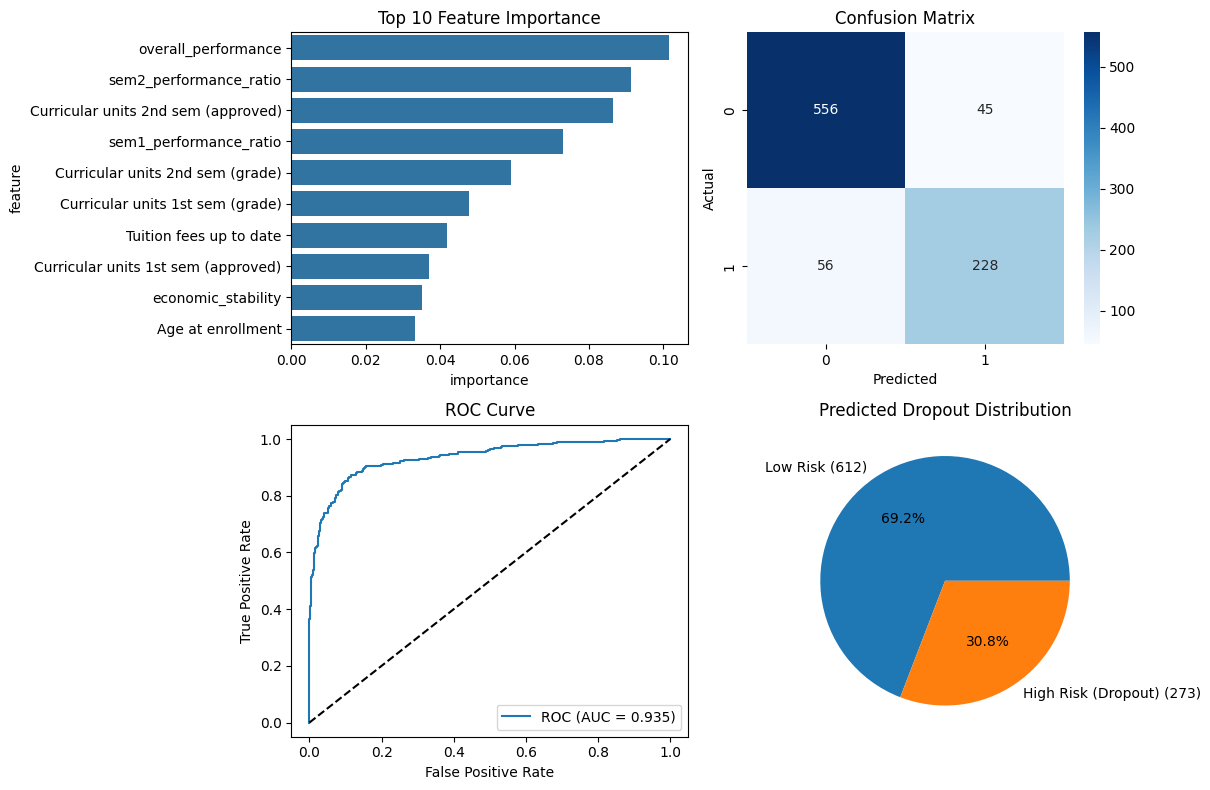


💾 Model saved as dropout_predictor.pkl

✅ Project completed successfully!

📁 Files generated:
   - dropout_predictor.pkl (trained model)
   - dropout_prediction_results.png (visualizations)


In [ ]:
# student_dropout_prediction_project
# Complete Student Dropout Prediction Model
# ========================================

!pip install imblearn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score # Added accuracy_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

class DropoutPredictor:
    def __init__(self):
        self.models = {}
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.feature_importance = None

    def load_data(self, filepath):
        """Step 1: Load and explore data"""
        print(" Loading dataset...")

        df = pd.read_csv('/content/dataset.csv')

        print(f"Dataset shape: {df.shape}")

        print("\nFirst 5 rows:")
        print(df.head())

        print(f"\nTarget distribution:\n\n{df['Target'].value_counts()}")

        print(f"\nMissing values:\n{df.isnull().sum().sum()}")
        return df







    def preprocess_data(self, df):
        """Step 2: Comprehensive data preprocessing"""

        print("\n🔧 Preprocessing data...")

        # Handle Target variable - map to binary (Dropout=1, Graduate/Enrolled=0)
        df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0, 'Enrolled': 0})

        # Identify categorical and numerical columns
        categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
        numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        numerical_cols.remove('Target')  # Remove target from features

        # Encode categorical variables
        for col in categorical_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            self.label_encoders[col] = le

        # Handle outliers using IQR method for key numerical features
        key_features = ['Previous qualification (grade)', 'Admission grade',
                       'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']
        for feature in key_features:
            if feature in df.columns:
                Q1 = df[feature].quantile(0.25)
                Q3 = df[feature].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                df[feature] = df[feature].clip(lower_bound, upper_bound)

        return df, numerical_cols







    def feature_engineering(self, df, numerical_cols):
        """Step 3: Feature engineering"""
        print("\n⚙️ Creating new features...")

        # Academic performance ratio
        df['sem1_performance_ratio'] = df['Curricular units 1st sem (approved)'] / (df['Curricular units 1st sem (enrolled)'] + 1)

        df['sem2_performance_ratio'] = df['Curricular units 2nd sem (approved)'] / (df['Curricular units 2nd sem (enrolled)'] + 1)

        df['overall_performance'] = (df['sem1_performance_ratio'] + df['sem2_performance_ratio']) / 2

        # Engagement ratio
        df['sem1_engagement'] = df['Curricular units 1st sem (evaluations)'] / (df['Curricular units 1st sem (enrolled)'] + 1)

        df['sem2_engagement'] = df['Curricular units 2nd sem (evaluations)'] / (df['Curricular units 2nd sem (enrolled)'] + 1)

        # Age group
        df['age_group'] = pd.cut(df['Age at enrollment'],
                                bins=[0, 20, 25, 30, 100],
                                labels=[0, 1, 2, 3])
        df['age_group'] = df['age_group'].astype(int)

        # Economic stability indicator
        df['economic_stability'] = (df['Tuition fees up to date'] +
                                  (1 - df['Debtor']) +
                                  df['Scholarship holder']).astype(int)

        numerical_cols.extend(['sem1_performance_ratio',
                               'sem2_performance_ratio',
                              'overall_performance',
                               'sem1_engagement',
                              'sem2_engagement',
                               'age_group',
                               'economic_stability'])


        return df, numerical_cols








    def feature_selection(self, X, y):
        """Step 4: Feature selection using Random Forest"""
        print("\n🎯 Feature selection...")
        rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_selector.fit(X, y)

        importances = rf_selector.feature_importances_
        indices = np.argsort(importances)[::-1]

        # Select top 20 features
        top_features_indices = indices[:20]
        self.feature_importance = pd.DataFrame({
            'feature': X.columns[top_features_indices],
            'importance': importances[top_features_indices]
        })

        print("\nTop 10 Most Important Features:")

        print("\n")



        print(self.feature_importance.head(10))

        return X.iloc[:, top_features_indices], self.feature_importance['feature'].tolist()







    def train_models(self, X_train, X_test, y_train, y_test):

        """Step 5: Train multiple models with hyperparameter tuning"""

        print("\n")


        print("\n🤖 Training models...")

        # Define models and parameter grids
        models = {
            'Logistic_Regression': {
                'model': LogisticRegression(random_state=42),
                'params': {'classifier__C': [0.1, 1, 10], 'classifier__max_iter': [1000]}
            },
            'Random_Forest': {
                'model': RandomForestClassifier(random_state=42),
                'params': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10, 20, None]}
            },
            'Gradient_Boosting': {
                'model': GradientBoostingClassifier(random_state=42),
                'params': {'classifier__n_estimators': [100, 200], 'classifier__learning_rate': [0.01, 0.1]}
            }
        }

        results = {}
        for name, config in models.items():
            print(f"\nTraining {name}...")

            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=42)),
                ('classifier', config['model'])
            ])

            grid_search = GridSearchCV(pipeline, config['params'],
                                     cv=5, scoring='f1', n_jobs=-1)
            grid_search.fit(X_train, y_train)

            y_pred = grid_search.predict(X_test)
            auc_score = roc_auc_score(y_test, grid_search.predict_proba(X_test)[:, 1])


            accuracy = accuracy_score(y_test, y_pred)  #NEW

            results[name] = {
                'model': grid_search.best_estimator_,
                'best_params': grid_search.best_params_,
                'train_score': grid_search.best_score_,
                'test_f1': f1_score(y_test, y_pred),
                'test_auc': auc_score,
                'predictions': y_pred,
                'accuracy': accuracy                   # NEW
            }

            print(f"Accuracy: {accuracy:.4f}")          # NEW

            print(f"Best params: {grid_search.best_params_}")
            print(f"CV F1: {grid_search.best_score_:.4f}, Test F1: {results[name]['test_f1']:.4f}")

        self.models = results
        return results







    def evaluate_models(self, X_test, y_test):
        """Step 6: Comprehensive model evaluation"""
        print("\n📈 Model Evaluation Summary:")

        results_df = pd.DataFrame({
            'Model': list(self.models.keys()),
            'CV_F1': [self.models[m]['train_score'] for m in self.models],
            'Test_F1': [self.models[m]['test_f1'] for m in self.models],
            'Test_AUC': [self.models[m]['test_auc'] for m in self.models]
        })

        print(results_df.round(4))

        # Best model
        best_model_name = results_df.loc[results_df['Test_F1'].idxmax(), 'Model']
        self.best_model = self.models[best_model_name]['model']
        print(f"\n🏆 Best Model: {best_model_name}")

        return best_model_name









    def plot_results(self, X_test, y_test, best_model_name):
        """Step 7: Visualization"""
        print("\n📊 Generating visualizations...")

        # Feature importance plot
        plt.figure(figsize=(12, 8))

        plt.subplot(2, 2, 1)
        sns.barplot(data=self.feature_importance.head(10), x='importance', y='feature')
        plt.title('Top 10 Feature Importance')


        # Confusion Matrix
        plt.subplot(2, 2, 2)
        y_pred = self.models[best_model_name]['predictions']
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')



        # ROC Curve
        plt.subplot(2, 2, 3)
        y_proba = self.models[best_model_name]['model'].predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})')
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()




        # Prediction distribution
        plt.subplot(2, 2, 4)
        risk_levels = ['Low Risk', 'High Risk (Dropout)']
        counts = pd.Series(y_pred).value_counts().sort_index()
        plt.pie(counts.values, labels=[f'{risk_levels[i]} ({v})' for i,v in enumerate(counts.values)], autopct='%1.1f%%')
        plt.title('Predicted Dropout Distribution')

        plt.tight_layout()
        plt.savefig('dropout_prediction_results.png', dpi=300, bbox_inches='tight')
        plt.show()

    def save_model(self, filename='dropout_predictor.pkl'):
        """Save the best model"""
        import joblib
        joblib.dump({
            'best_model': self.best_model,
            'scaler': self.scaler,
            'label_encoders': self.label_encoders,
            'feature_importance': self.feature_importance
        }, filename)
        print(f"\n💾 Model saved as {filename}")

    def predict_new_student(self, new_data):
        """Predict dropout risk for new student"""
        # new_data should be a dict with same features as training data
        df_new = pd.DataFrame([new_data])

        # Apply same preprocessing
        for col in self.label_encoders:
            if col in df_new.columns:
                df_new[col] = self.label_encoders[col].transform(df_new[col].astype(str))

        # Select same features and predict
        X_new = df_new[self.feature_importance['feature'].tolist()]
        X_new_scaled = self.scaler.transform(X_new)
        prediction = self.best_model.predict(X_new_scaled)[0]
        probability = self.best_model.predict_proba(X_new_scaled)[0, 1]

        risk = "High Risk (Likely Dropout)" if prediction == 1 else "Low Risk"
        print(f"🎯 Prediction: {risk}")
        print(f"Dropout Probability: {probability:.2%}")
        return prediction, probability


















def main():
    """Main execution function"""

    print("🚀 Student Dropout Prediction Project")
    print("=" * 50)

    # Initialize predictor
    predictor = DropoutPredictor()

    # Complete pipeline
    # Make sure 'dataset.csv' is in the same directory as this notebook or provide the full path to your dataset.
    # For example: df = predictor.load_data('/content/drive/MyDrive/my_data.csv')


    df = predictor.load_data('dataset.csv')
    df_processed, num_cols = predictor.preprocess_data(df)
    df_engineered, num_cols = predictor.feature_engineering(df_processed, num_cols)

    # Prepare features and target
    X = df_engineered.drop('Target', axis=1)
    y = df_engineered['Target']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        random_state=42, stratify=y)

    # Feature selection
    X_train_selected, selected_features = predictor.feature_selection(X_train, y_train)
    X_test_selected = X_test[selected_features]

    # Train models
    results = predictor.train_models(X_train_selected, X_test_selected, y_train, y_test)

    # Evaluate
    best_model = predictor.evaluate_models(X_test_selected, y_test)

    # Visualize
    predictor.plot_results(X_test_selected, y_test, best_model)

    # Save model
    predictor.save_model()

    print("\n✅ Project completed successfully!")
    print("\n📁 Files generated:")
    print("   - dropout_predictor.pkl (trained model)")
    print("   - dropout_prediction_results.png (visualizations)")

if __name__ == "__main__":
    from sklearn.metrics import f1_score  # Import needed for f1_score
    main()